# Notebook to set the bridges to approximately the right place in the chainage

### Import necessary libraries

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Import dataset of bridges

In [75]:
df_bridges = pd.read_excel('../data/raw/BMMS_overview.xlsx')
df_bridges.head()

,road,km,type,LRPName,name,length,condition,structureNr,roadName,chainage,width,constructionYear,spans,zone,circle,division,sub-division,lat,lon,EstimatedLoc
0,N1,1.800,Box Culvert,LRP001a,.,11.30,A,117861,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,1.8,19.5,2005.0,2.0,Dhaka,Dhaka,Narayanganj,Narayanganj-1,23.702889,90.450389,bcs1
1,N1,4.925,Box Culvert,LRP004b,.,6.60,A,117862,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,4.925,35.4,2006.0,1.0,Dhaka,Dhaka,Narayanganj,Narayanganj-1,23.693611,90.478833,bcs1
2,N1,8.976,PC Girder Bridge,LRP008b,Kanch pur Bridge.,394.23,A,119889,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,8.976,NaN,NaN,NaN,Dhaka,Dhaka,Narayanganj,Narayanganj-1,23.704583,90.518833,road_precise
3,N1,10.880,Box Culvert,LRP010b,NOYAPARA CULVERT,6.30,A,112531,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,10.88,12.2,1992.0,2.0,Dhaka,Dhaka,Narayanganj,Vitikandi,23.699833,90.530722,bcs1
4,N1,10.897,Box Culvert,LRP010c,ADUPUR CULVERT,6.30,A,112532,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,10.897,12.2,1984.0,2.0,Dhaka,Dhaka,Narayanganj,Vitikandi,23.699667,90.530722,bcs1


### Import dataset of roads

In [76]:
df_roads = pd.read_csv('../data/processed/_roads.tsv', sep='\t')
all_data = []

for rd in df_roads.itertuples(index=False):
    rd_name = rd[0]

    for i in range(1, len(rd)-2, 3):
        lrp = rd[i]
        lat = rd[i+1]
        lon = rd[i+2]

        if pd.isna(lrp) and pd.isna(lat) and pd.isna(lon):
            continue

        all_data.append((rd_name, lrp, lat, lon))

df_roads1 = pd.DataFrame(all_data, columns=["road", "LRP", "LAT", "LON"])
df_roads1.to_pickle('../data/processed/roads_long_format.pkl')


C:\Users\niels\AppData\Local\Temp\ipykernel_31492\3814492574.py:1: DtypeWarning: Columns (571,574,577,580,583,586,589,592,595,598,601,604,607,610,613,616,619,622,625,628,631,634,637,640,643,646,649,652,655,658,661,664,667,670,673,676,679,682,685,688,691,694,697,700,703,706,709,712,715,718,721,724,727,730,733,736,739,742,745,748,751,754,757,760,763,766,769,772,775,778,781,784,787,790,793,796,799,802,805,808,811,814,817,820,823,826,829,832,835,838,841,844,847,850,853,856,859,862,865,868,871,874,877,880,883,886,889,892,895,898,901,904,907,910,913,916,919,922,925,928,931,934,937,940,943,946,949,952,955,958,961,964,967,970,973,976,979,982,985,988,991,994,997,1000,1003,1006,1009,1012,1015,1018,1021,1024,1027,1030,1033,1036,1039,1042,1045,1048,1051,1054,1057,1060,1063,1066,1069,1072,1075,1078,1081,1084,1087,1090,1093,1096,1099,1102,1105,1108,1111,1114,1117,1120,1123,1126,1129,1132,1135,1138,1141,1144,1147,1150,1153,1156,1159,1162,1165,1168,1171,1174,1177,1180,1183,1186,1189,1192,1195,1198,120

In [77]:
df_error_bridges =df_bridges[df_bridges['EstimatedLoc'] == 'error']

df_error_bridges1 = df_error_bridges[['road', 'km','LRPName', 'chainage', 'lat', 'lon']]
df_error_bridges1.head(10)

,road,km,LRPName,chainage,lat,lon
6277,Z1102,7.282,LRP007a,7.282,NaN,NaN
7227,Z1602,23.760,LRP024a,23.76,NaN,NaN
7228,Z1602,24.066,LRP024c,24.066,NaN,NaN
7231,Z1602,36.394,LRP036a,36.394,NaN,NaN
7976,Z2063,4.100,LRP005a,4.1,NaN,NaN
12020,Z1065,27.924,LRP027b,27.924,NaN,NaN
13115,Z6856,46.777,LRP047b,46.777,NaN,NaN
13169,Z7045,20.250,LRP019b,20.25,NaN,NaN
13375,Z8204,9.744,LRP009f,9.744,NaN,NaN
14693,Z8048,3.840,LRP003e,3.84,NaN,NaN


In [78]:
merged = df_error_bridges1.merge(
    df_roads1[['road', 'LRP', 'LAT', 'LON']],
    left_on=['road', 'LRPName'],
    right_on=['road', 'LRP'],
    how='left'
)

merged['lat'] = merged['LAT'].combine_first(merged['lat'])
merged['lon'] = merged['LON'].combine_first(merged['lon'])

df_error_bridges1 = merged.drop(columns=['LRP', 'LAT', 'LON'])
df_error_bridges1.head(10)

,road,km,LRPName,chainage,lat,lon
0,Z1102,7.282,LRP007a,7.282,NaN,NaN
1,Z1602,23.760,LRP024a,23.76,NaN,NaN
2,Z1602,24.066,LRP024c,24.066,NaN,NaN
3,Z1602,36.394,LRP036a,36.394,NaN,NaN
4,Z2063,4.100,LRP005a,4.1,NaN,NaN
5,Z1065,27.924,LRP027b,27.924,NaN,NaN
6,Z6856,46.777,LRP047b,46.777,NaN,NaN
7,Z7045,20.250,LRP019b,20.25,NaN,NaN
8,Z8204,9.744,LRP009f,9.744,NaN,NaN
9,Z8048,3.840,LRP003e,3.84,NaN,NaN


In [83]:
df_error_bridges1['Road LRP'] = df_error_bridges1['road'] + ' ' + df_error_bridges1['LRPName']

df_roads1['Road LRP'] = df_roads1['road'] + ' ' + df_roads1['LRP']

df_bridges_road_interpolate = df_bridges[(df_bridges['EstimatedLoc'] == 'road_interpolate') | (df_bridges['EstimatedLoc'] == 'error')]
df_bridges_road_interpolate['Road LRP'] = df_bridges_road_interpolate['road'] + ' ' + df_bridges_road_interpolate['LRPName']

C:\Users\niels\AppData\Local\Temp\ipykernel_31492\1681074680.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bridges_road_interpolate['Road LRP'] = df_bridges_road_interpolate['road'] + ' ' + df_bridges_road_interpolate['LRPName']


In [84]:
df_info = pd.read_csv('../data/raw/Roads_InfoAboutEachLRP.csv')
df_info['Road LRP'] = df_info['road'] + ' ' + df_info['lrp']
df_info = df_info[['Road LRP', 'chainage']]
df_roads_with_chainage = df_roads1.merge(df_info, left_on='Road LRP', right_on='Road LRP')


In [85]:
def find_coordinates_for_bridge_based_on_lrps(bridge_x, df_bridges_x, df_roads_chainage_x):
    bridge_df = df_bridges_x[df_bridges_x['Road LRP'] == bridge_x]
    road_name = bridge_df.road.values[0]
    road = df_roads_chainage_x[df_roads_chainage_x['road'] == road_name]
    for index1 in range(len(road)):
        if float(bridge_df.km.values[0]) < road.iloc[index1].chainage:
            before = road.iloc[index1-1]
            after = road.iloc[index1]
            scale = (after.chainage - before.chainage) / (before.chainage + 0.0001)
            lat_diff = after.LAT - before.LAT
            lon_diff = after.LON - before.LON
            coord =  (before.LAT + lat_diff * scale, before.LON + lon_diff * scale)
            return coord
    print('Not found')        


In [86]:
df_bridges_fix = df_bridges_road_interpolate.copy()
df_bridges_fix.set_index('Road LRP', inplace=True)

bridges_no_fix = []
bridges_none = []
for bridge in df_bridges_road_interpolate['Road LRP']:
    coords = find_coordinates_for_bridge_based_on_lrps(bridge, df_bridges_road_interpolate, df_roads_with_chainage)
    if coords is not None:
        if coords[0] < 19 or coords[0] > 27:
            print(bridge, coords, 'Out of bounds, change did not work')
            bridges_no_fix.append(bridge)
        elif coords[1] < 85 or coords[1] > 95:
            print(bridge, coords, 'Out of bounds, change did not work')
            bridges_no_fix.append(bridge)
        else:
            df_fix = pd.DataFrame({'lat': coords[0], 'lon': coords[1]}, index=[bridge])
            df_bridges_fix.update(df_fix)
    else:
        print('Coordinates could not be defined based on chainage', bridge)
        bridges_none.append(bridge)

print(bridges_no_fix, 'The amount of bridges with no coordinates found on basis of chainage is ',len(bridges_no_fix))
print(bridges_none, 'The bridges that are not found based on chainage is ',len(bridges_none))

Z1013 LRPsd (56.075951000006015, 77.34869410001355) Out of bounds, change did not work
Z1013 LRP001c (56.075951000006015, 77.34869410001355) Out of bounds, change did not work
Not found
Coordinates could not be defined based on chainage Z1102 LRP007a
Not found
Coordinates could not be defined based on chainage Z1602 LRP024a
Not found
Coordinates could not be defined based on chainage Z1602 LRP024c
Not found
Coordinates could not be defined based on chainage Z1602 LRP036a
Not found
Coordinates could not be defined based on chainage Z2063 LRP005a
Z1013 LRP001a (56.075951000006015, 77.34869410001355) Out of bounds, change did not work
Not found
Coordinates could not be defined based on chainage Z1065 LRP027b
Z2807 LRP001a (24.6033158000105, 72.36263409999574) Out of bounds, change did not work
Not found
Coordinates could not be defined based on chainage Z2813 LRP011a
Not found
Coordinates could not be defined based on chainage Z2813 LRP018a
Not found
Coordinates could not be defined based

Text(0.5, 1.0, 'Fixed bridges (bounded to Bangladesh)')

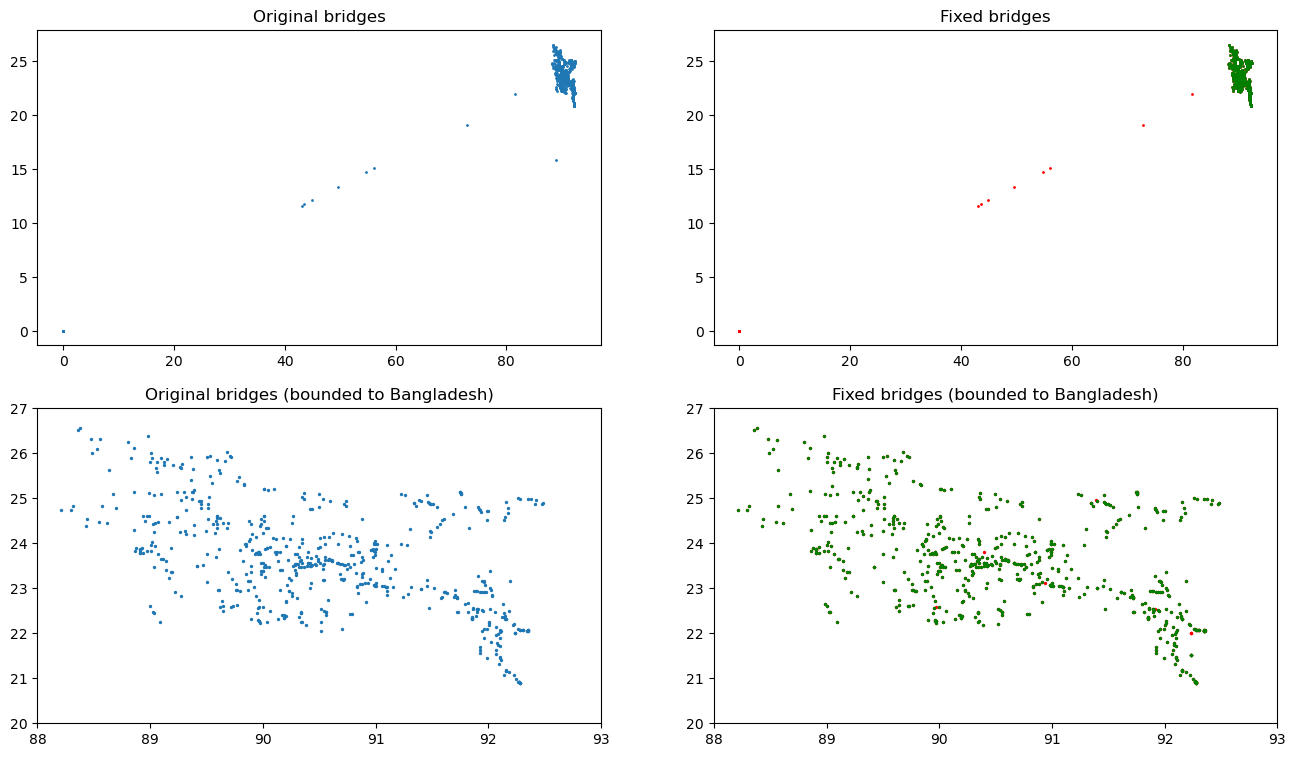

In [87]:
f, axes = plt.subplots(2,2, figsize=(16,9))
axes = axes.flatten()
df_indices_fixed = list(set(df_bridges_fix.index) - set(bridges_no_fix) - set(bridges_none))
df_bridges_fixed_indices = df_bridges_fix.loc[df_indices_fixed]
axes[0].scatter(df_bridges_road_interpolate['lon'], df_bridges_road_interpolate['lat'], s=1)
axes[1].scatter(df_bridges_fix['lon'], df_bridges_fix['lat'], c='red', s=1)
axes[1].scatter(df_bridges_fixed_indices['lon'], df_bridges_fixed_indices['lat'], c='green', s=1)

axes[2].set_xlim(88.0, 93.0)  # Longitude bounds
axes[2].set_ylim(20.0, 27.0)

axes[3].set_xlim(88.0, 93.0)  # Longitude bounds
axes[3].set_ylim(20.0, 27.0)

axes[2].scatter(df_bridges_road_interpolate['lon'], df_bridges_road_interpolate['lat'], s=2)
axes[3].scatter(df_bridges_fix['lon'], df_bridges_fix['lat'], c='red', s=2)
axes[3].scatter(df_bridges_fixed_indices['lon'], df_bridges_fixed_indices['lat'], c='green', s=2)

axes[0].set_title('Original bridges')
axes[1].set_title('Fixed bridges')
axes[2].set_title('Original bridges (bounded to Bangladesh)')
axes[3].set_title('Fixed bridges (bounded to Bangladesh)')



In [ ]:
import geopandas as gpd
from shapely.geometry import Point

In [ ]:
world = gpd.read_file("../data/raw/ne_10m_admin_0_countries.shp")

bangladesh = world[world['ADMIN'] == 'Bangladesh'].copy()
bangladesh = bangladesh.set_crs("EPSG:4326", allow_override=True)

bd_geom = bangladesh.geometry.buffer(0).union_all()

gdf_points = gpd.GeoDataFrame(
    df_bridges,
    geometry=gpd.points_from_xy(df_bridges['lon'], df_bridges['lat']),
    crs="EPSG:4326"
)

utm_crs = "EPSG:32646"
bangladesh_m = bangladesh.to_crs(utm_crs)
gdf_points_m = gdf_points.to_crs(utm_crs)

bd_geom_m = bangladesh_m.geometry.buffer(0).union_all()

gdf_points_m["distance_to_bd_m"] = gdf_points_m.geometry.distance(bd_geom_m)

threshold_m = 5_000  # 50 km in meters
gdf_points_m["far_outside_bd"] = gdf_points_m["distance_to_bd_m"] > threshold_m

gdf_points["distance_to_bd_km"] = gdf_points_m["distance_to_bd_m"] / 1000
gdf_points["far_outside_bd"] = gdf_points_m["far_outside_bd"].values




DataSourceError: ../data/raw/ne_10m_admin_0_countries.shp: No such file or directory

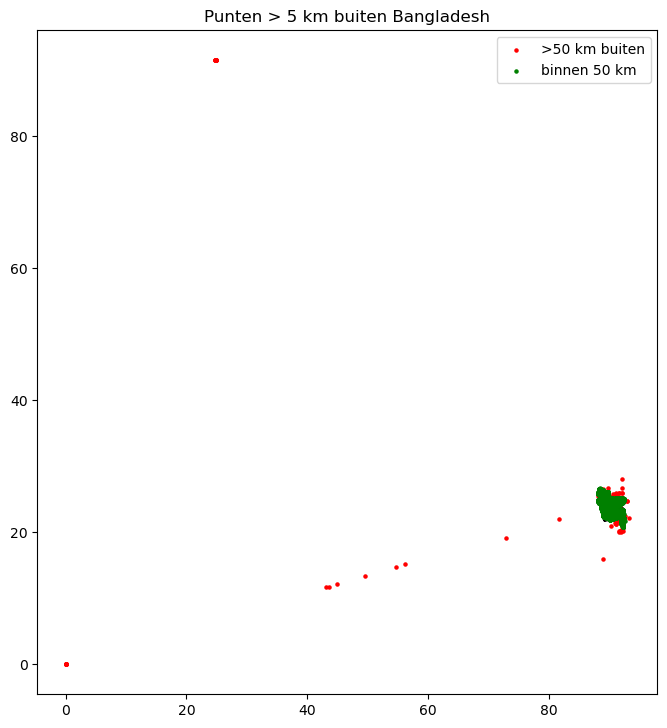

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))
bangladesh.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
gdf_points[gdf_points["far_outside_bd"]].plot(ax=ax, color="red", markersize=5, label=">50 km buiten")
gdf_points[~gdf_points["far_outside_bd"]].plot(ax=ax, color="green", markersize=5, label="binnen 50 km")
plt.legend()
plt.title("Punten > 5 km buiten Bangladesh")
plt.show()

In [ ]:
gdf_points.head(10)
far_points = gdf_points[gdf_points["far_outside_bd"]]
far_points_selected = far_points[["road", "LRPName", "lat", "lon"]]
print(far_points_selected)


        road  LRPName        lat        lon
855       N2  LRP247a  25.963389  92.019083
2083    N108  LRP014b  20.155611  92.178889
2280    R151  LRP005d  21.924028  91.558611
2469    R164    LRPSa  22.503194  92.640028
2516    R170  LRP035b  20.067056  91.937722
...      ...      ...        ...        ...
21130  Z5452  LRP027b        NaN        NaN
21281  Z7602  LRP013b  15.869151  88.989909
21309  Z7718  LRP038a   0.000000   0.000000
21362  Z8203  LRP001a   0.000000   0.000000
21396  Z8708  LRP074a        NaN        NaN

[197 rows x 4 columns]


In [ ]:
merged = far_points_selected.merge(
    df_roads1[['road', 'LRP', 'LAT', 'LON']],
    left_on=['road', 'LRPName'],                
    right_on=['road', 'LRP'],                  
    how='left'
)

merged['lat'] = merged['LAT'].combine_first(merged['lat'])
merged['lon'] = merged['LON'].combine_first(merged['lon'])

merged['matched'] = merged['LAT'].notna() & merged['LON'].notna()
far_points_selected_updated = merged.drop(columns=['LRP', 'LAT', 'LON'])


far_points_selected_updated[far_points_selected_updated['matched'] == False]

mask = far_points_selected_updated['lat'] > 80

# Wissel lat en lon voor deze punten
far_points_selected_updated.loc[mask, ['lat', 'lon']] = \
    far_points_selected_updated.loc[mask, ['lon', 'lat']].values

# Controleer resultaat
far_points_selected_updated[mask].head()



,road,LRPName,lat,lon,matched
7,R241,LRP029a,24.805111,91.543889,False
12,R241,LRP036a,24.855083,91.514083,False
110,R241,LRP028c,24.796694,91.542083,False
121,R241,LRP035c,24.849861,91.516167,False


In [ ]:
df_bridges_updated = df_bridges.copy()

df_bridges_updated = df_bridges_updated.merge(
    far_points_selected_updated[['road', 'LRPName', 'lat', 'lon', 'matched']],
    on=['road', 'LRPName'],
    how='left',
    suffixes=('', '_far')
)

df_bridges_updated['lat'] = df_bridges_updated['lat_far'].combine_first(df_bridges_updated['lat'])
df_bridges_updated['lon'] = df_bridges_updated['lon_far'].combine_first(df_bridges_updated['lon'])

df_bridges_updated['matched'] = df_bridges_updated['matched'].fillna(False)

df_bridges_updated = df_bridges_updated.drop(columns=['lat_far', 'lon_far'])

df_bridges_updated.head(10)

C:\Users\niels\AppData\Local\Temp\ipykernel_16444\3328262776.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bridges_updated['matched'] = df_bridges_updated['matched'].fillna(False)


,road,km,type,LRPName,name,length,condition,structureNr,roadName,chainage,...,constructionYear,spans,zone,circle,division,sub-division,lat,lon,EstimatedLoc,matched
0,N1,1.800,Box Culvert,LRP001a,.,11.30,A,117861,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,1.8,...,2005.0,2.0,Dhaka,Dhaka,Narayanganj,Narayanganj-1,23.702889,90.450389,bcs1,False
1,N1,4.925,Box Culvert,LRP004b,.,6.60,A,117862,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,4.925,...,2006.0,1.0,Dhaka,Dhaka,Narayanganj,Narayanganj-1,23.693611,90.478833,bcs1,False
2,N1,8.976,PC Girder Bridge,LRP008b,Kanch pur Bridge.,394.23,A,119889,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,8.976,...,NaN,NaN,Dhaka,Dhaka,Narayanganj,Narayanganj-1,23.704583,90.518833,road_precise,False
3,N1,10.880,Box Culvert,LRP010b,NOYAPARA CULVERT,6.30,A,112531,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,10.88,...,1992.0,2.0,Dhaka,Dhaka,Narayanganj,Vitikandi,23.699833,90.530722,bcs1,False
4,N1,10.897,Box Culvert,LRP010c,ADUPUR CULVERT,6.30,A,112532,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,10.897,...,1984.0,2.0,Dhaka,Dhaka,Narayanganj,Vitikandi,23.699667,90.530722,bcs1,False
5,N1,11.296,Box Culvert,LRP011a,NAYABARI KASPUR BOX CULVERT,8.30,A,101110,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,11.296,...,1986.0,2.0,Dhaka,Dhaka,Narayanganj,Vitikandi,23.697361,90.533833,bcs1,False
6,N1,12.239,Box Culvert,LRP012a,KHAS PARA BOX CULVERT,9.30,A,101117,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,12.239,...,1986.0,2.0,Dhaka,Dhaka,Narayanganj,Vitikandi,23.692333,90.541000,bcs1,False
7,N1,12.253,Box Culvert,LRP012b,DAWAN BAG BOX CULVERT,6.10,A,101119,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,12.253,...,1987.0,2.0,Dhaka,Dhaka,Narayanganj,Vitikandi,23.692556,90.541139,bcs1,False
8,N1,12.660,PC Girder Bridge,LRP013a,Madanpur Bridge.(L),27.50,A,119897,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,12.66,...,NaN,NaN,Dhaka,Dhaka,Narayanganj,Vitikandi,23.685500,90.551278,road_precise,False
9,N1,12.660,PC Girder Bridge,LRP013a,MADAN PUR (R),26.30,A,109841,Dhaka (Jatrabari)-Comilla (Mainamati)-Chittago...,12.66,...,2003.0,1.0,Dhaka,Dhaka,Narayanganj,Vitikandi,23.691111,90.544889,bcs1,False


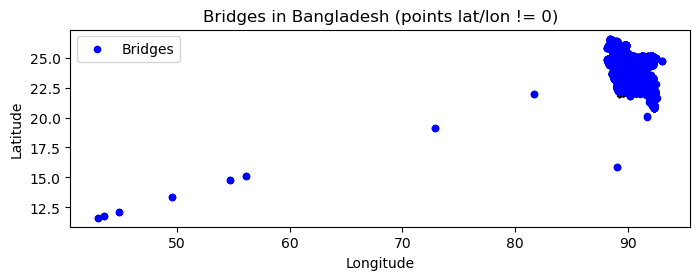

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt


df_plot = df_bridges_updated[(df_bridges_updated['lat'] != 0.0) & (df_bridges_updated['lon'] != 0.0)]

gdf_bridges = gpd.GeoDataFrame(
    df_plot,
    geometry=gpd.points_from_xy(df_plot['lon'], df_plot['lat']),
    crs="EPSG:4326"
)


world = gpd.read_file("../data/raw/ne_10m_admin_0_countries.shp")
bangladesh = world[world['ADMIN'] == 'Bangladesh']

fig, ax = plt.subplots(figsize=(8, 10))
bangladesh.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
gdf_bridges.plot(ax=ax, color='blue', markersize=20, label='Bridges')

plt.title("Bridges in Bangladesh (points lat/lon != 0)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()